In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Load the data

In [2]:
bd = pd.read_csv('/kaggle/input/datasets/mahmudulsakib2019/temp-and-rain/Temp_and_rain.csv')

In [3]:
bd.head()

,tem,Month,Year,rain
0,16.9760,1,1901,18.5356
1,19.9026,2,1901,16.2548
2,24.3158,3,1901,70.7981
3,28.1834,4,1901,66.1616
4,27.8892,5,1901,267.2150


In [4]:
bd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1380 entries, 0 to 1379
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   tem     1380 non-null   float64
 1   Month   1380 non-null   int64  
 2   Year    1380 non-null   int64  
 3   rain    1380 non-null   float64
dtypes: float64(2), int64(2)
memory usage: 43.3 KB


In [5]:
bd.describe()

,tem,Month,Year,rain
count,1380.000000,1380.000000,1380.00000,1380.000000
mean,25.066213,6.500000,1958.00000,203.275431
std,3.682411,3.453304,33.20842,202.730898
min,16.800600,1.000000,1901.00000,0.000000
25%,22.114125,3.750000,1929.00000,18.498850
50%,27.012950,6.500000,1958.00000,145.086000
75%,28.007850,9.250000,1987.00000,347.639500
max,29.526000,12.000000,2015.00000,1012.020000


## 2. Exploratory Data Analysis
Check for missing values, then visualize relationships between temperature, month, year and rainfall.

In [6]:
bd.isna().sum()

tem      0
Month    0
Year     0
rain     0
dtype: int64

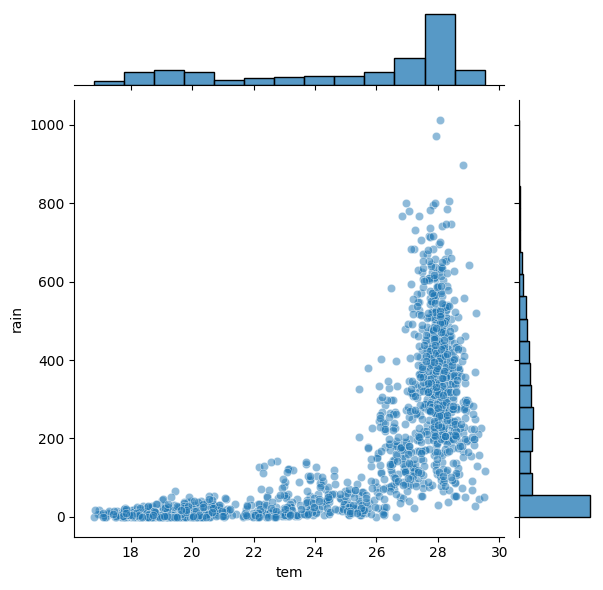

In [7]:
sns.jointplot(x='tem', y='rain', data=bd, alpha=0.5)

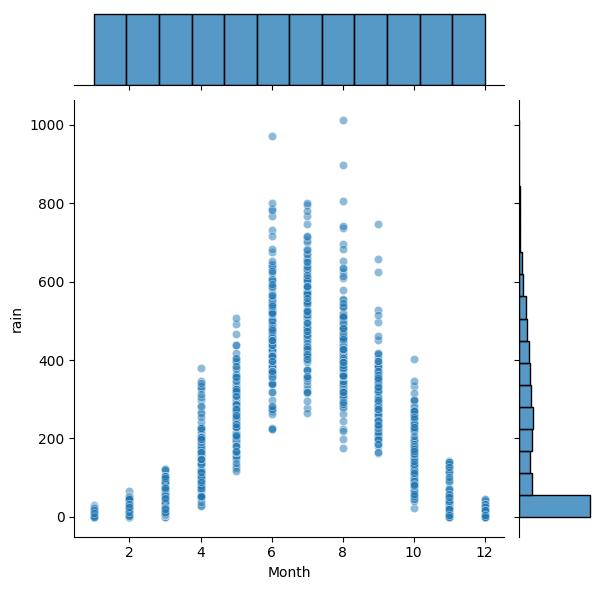

In [8]:
sns.jointplot(x='Month', y='rain', data=bd, alpha=0.5)

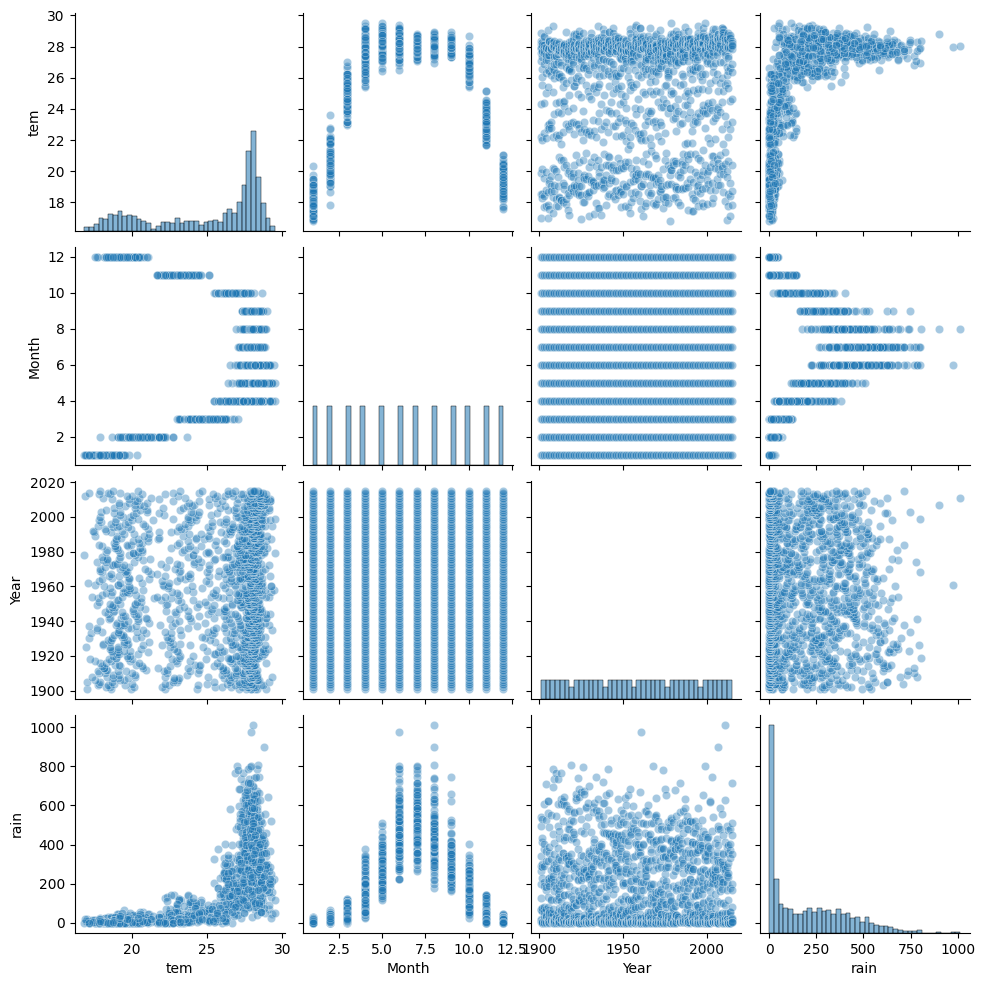

In [9]:
sns.pairplot(bd,kind='scatter',plot_kws={'alpha':0.4},diag_kws={'alpha':0.55, 'bins':40})

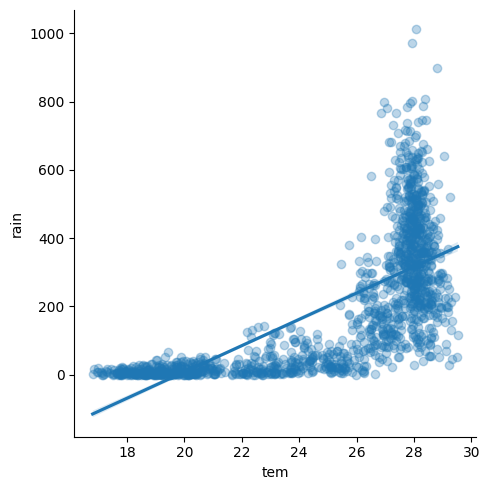

In [10]:
sns.lmplot(x='tem',y='rain',data=bd,scatter_kws={'alpha':0.3})

## 3. Train / Test Split

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
X = bd[['tem', 'Month', 'Year']]
y = bd['rain']

In [13]:
X.head()
y.head()

0     18.5356
1     16.2548
2     70.7981
3     66.1616
4    267.2150
Name: rain, dtype: float64

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## 4. Train the Linear Regression Model

In [15]:
from sklearn.linear_model import LinearRegression

In [16]:
lm = LinearRegression()

In [17]:
lm.fit(X_train, y_train)

LinearRegression()

In [18]:
lm.coef_

array([38.41498133,  1.25687467, -0.38282717])

In [19]:
lm.score(X, y)

0.4943166256677711

In [20]:
cdf = pd.DataFrame(lm.coef_, X.columns, columns=['Coef'])
print(cdf)

            Coef
tem    38.414981
Month   1.256875
Year   -0.382827


## 5. Statsmodels OLS Summary
A more detailed statistical summary of the regression (coefficients, p-values, R², etc.)

In [21]:
import statsmodels.api as sm
X_sm = sm.add_constant(X_train)
model = sm.OLS(y_train, X_sm)
model_fit = model.fit()
print(model_fit.summary())

                            OLS Regression Results                            
Dep. Variable:                   rain   R-squared:                       0.502
Model:                            OLS   Adj. R-squared:                  0.501
Method:                 Least Squares   F-statistic:                     323.5
Date:                Fri, 28 Aug 2026   Prob (F-statistic):          3.34e-145
Time:                        15:02:30   Log-Likelihood:                -6158.9
No. Observations:                 966   AIC:                         1.233e+04
Df Residuals:                     962   BIC:                         1.235e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -18.1538    265.789     -0.068      0.9

## 6. Predictions on the Test Set


In [22]:
predictions = lm.predict(X_test)

Text(0.5, 1.0, 'Actual Rainfall vs. Model Predictions')

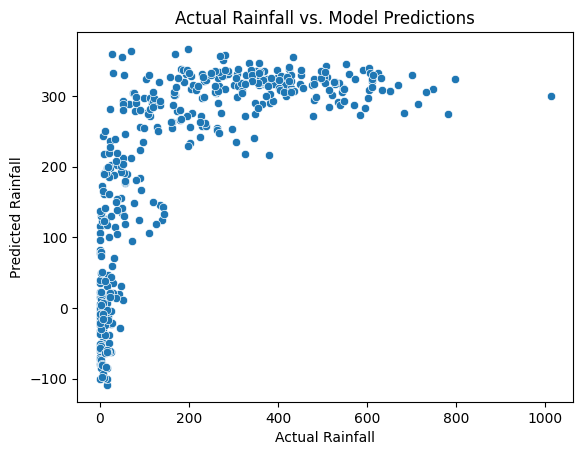

In [23]:
sns.scatterplot(x=y_test, y=predictions)
plt.xlabel('Actual Rainfall')
plt.ylabel('Predicted Rainfall')
plt.title('Actual Rainfall vs. Model Predictions')

## 7. Evaluate Model Performance

In [24]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import math

print('Mean Absolute Error:', mean_absolute_error(y_test, predictions))
print('Mean Squared Error:', mean_squared_error(y_test, predictions))
print('Root Mean Squared Error:', math.sqrt(mean_squared_error(y_test, predictions)))

Mean Absolute Error: 113.68804044755196
Mean Squared Error: 22089.608760701663
Root Mean Squared Error: 148.62573384411485


## 8. Residual Analysis
Check whether residuals are roughly normally distributed (an assumption of linear regression).

Text(0.5, 1.0, 'Distribution of Residuals')

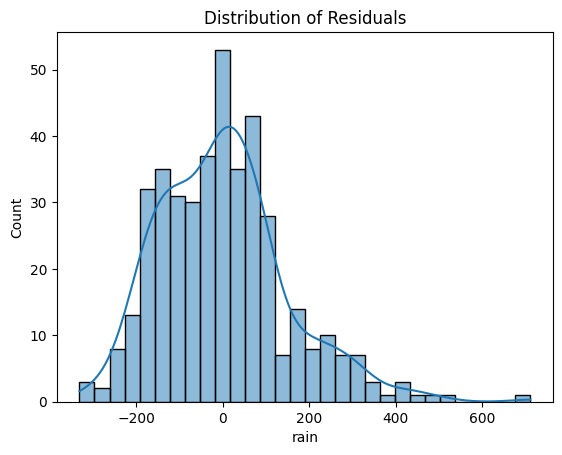

In [25]:
residuals = y_test - predictions
sns.histplot(residuals, bins=30, kde=True)
plt.title('Distribution of Residuals')

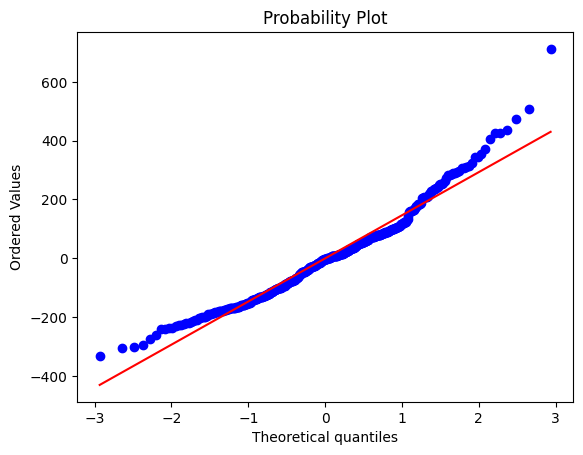

In [26]:
import pylab
import scipy.stats as stats

stats.probplot(residuals, dist="norm", plot=pylab)
pylab.show()

## 8. Correlation HeatMap 


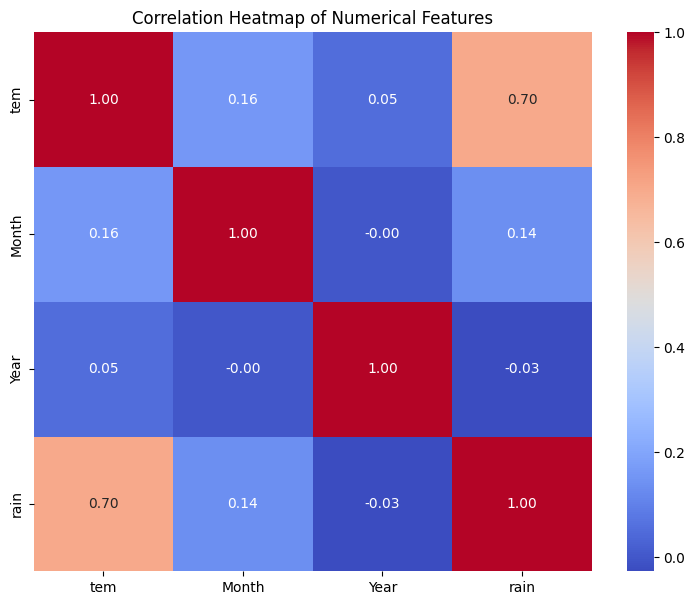

In [27]:
plt.figure(figsize=(9, 7))
sns.heatmap(bd.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()